## MACHINE LEARNING PROJECT - COLLEGE BASKETBALL DATASET.

### Description.

- The dataset `cbb.xlsx` contains 1406 entries and 24 columns, with no missing values.
- It is a college basketball statistics for various teams across different years.

### 1. Dataset Loading
- Down below is a code for hoew I loaded the dataset


In [1]:
from pathlib import Path # For handling file paths in a cross platform way 
import pandas as pd # For data manipulation and analysis, especially for working with tabular data

# Set the notebook's current directory and construct the path to the data file
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / "data" / "cbb.csv"
# Read the CSV file into a pandas DataFrame and display the first few rows to verify that it was loaded correctly
df = pd.read_csv(data_path)
df.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Villanova,BE,40,35,123.1,90.9,0.9703,56.1,46.7,16.3,...,30.0,57.4,44.1,36.2,33.9,66.7,8.9,Champions,2.0,2016
2,Notre Dame,ACC,36,24,118.3,103.3,0.8269,54.0,49.5,15.3,...,26.0,52.9,46.5,37.4,36.9,65.5,2.3,E8,6.0,2016
3,Virginia,ACC,37,29,119.9,91.0,0.9600,54.8,48.4,15.1,...,33.4,52.6,46.3,40.3,34.7,61.9,8.6,E8,1.0,2016
4,Kansas,B12,37,32,120.9,90.4,0.9662,55.7,45.1,17.8,...,37.3,52.7,43.4,41.3,32.5,70.1,11.6,E8,1.0,2016


### 2. Data Quality Audit Report

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / "data" / "cbb.csv"
df = pd.read_csv(data_path)
print("Dataset Loaded Successfully!")
print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns\n")

# 1. Basic overview

print("="*55)
print("1. Basic Overview")
print("="*55)

print("\n Column Names & Data Types:")
print(df.dtypes)

print(f"\n  Numerical Columns: {df.select_dtypes(include=np.number).columns.tolist()}")
print(f"\n  Categorical Columns: {df.select_dtypes(include='object').columns.tolist()}")

# 2. Missing Values
print("\n" + "="*55)
print("2. Missing Values")
print("="*55)

missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
}).query("`Missing Count` > 0").sort_values(by="Missing %", ascending=False)

if missing_report.empty:
    print("\n No missing values found.")
else:
    print("\n Missing Values:")
    print(missing_report)

# 3. Duplicate rows.

print("\n" + "="*55)
print("3. Duplicate Rows")
print("="*55)

duplicate_rows = df.duplicated()
if duplicate_rows.any():
    print(f"\n Number of duplicate rows: {duplicate_rows.sum()}")
else:
    print("\n No duplicate rows found.")

# 4. Statistical summary of numerical columns.
print("\n" + "="*55)
print("4. Statistical Summary of Numerical Columns")
print("="*55)

print(df.describe().T.round(2))# Transpose for better readability and round to 2 decimal places

# 5. Outlier Detection (IQR method)

print("\n" + "="*55)
print("5. Outlier Detection (IQR method)")
print("="*55)

numeric_cols = df.select_dtypes(include=np.number).columns
outliers_report = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_report[col] = {
        "Outlier Count": len(outliers),
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound
    }

if outliers_report:
    print("\n Outliers Detected:")
    print(pd.DataFrame(outliers_report).T.sort_values(by="Outlier Count", ascending=False))
else:
    print("\n No outliers detected using the IQR method.")

# 6. Categorical Column Quality. (value checks, unique values, etc.)
print("\n" + "="*55)
print("6. Categorical Column Quality")
print("="*55)

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    unique_values = df[col].nunique()
    print(f"\n Column: {col}")
    print(f" Unique Values: {unique_values}")
    if unique_values < 20:
        print(f" Value Counts:\n{df[col].value_counts()}")
    else:
        print(" Too many unique values to display value counts.")

# 7. Overall Data Quality Score
print("\n" + "="*55)
print("7. Overall Data Quality Score")
print("="*55)

completeness = round((1 - df.isnull().mean().mean())*100, 2)
uniqueness = round((1 - df.duplicated().mean())*100, 2)
outlier_cols = len(outliers_report)
consistency = round((1 - (outlier_cols / len(numeric_cols)))*100, 2) if numeric_cols.size > 0 else 100
quality_score = round((completeness + uniqueness + consistency) / 3, 2)

print(f"""
      Completeness (no missing values): {completeness}%
      Uniqueness (no duplicates): {uniqueness}%
      Consistency (no outliers): {consistency}%
      Overall Quality Score: {quality_score}%
      """)

if quality_score >= 90:
    print("Excellent data quality. Ready for modelling!")
elif quality_score >= 75:
    print("Good data quality. Some minor issues to address before modelling.")
else:
    print("Data quality needs improvement before modelling.")


Dataset Loaded Successfully!
Shape: 1,406 rows and 24 columns

1. Basic Overview

 Column Names & Data Types:
TEAM              str
CONF              str
G               int64
W               int64
ADJOE         float64
ADJDE         float64
BARTHAG       float64
EFG_O         float64
EFG_D         float64
TOR           float64
TORD          float64
ORB           float64
DRB           float64
FTR           float64
FTRD          float64
2P_O          float64
2P_D          float64
3P_O          float64
3P_D          float64
ADJ_T         float64
WAB           float64
POSTSEASON        str
SEED          float64
YEAR            int64
dtype: object

  Numerical Columns: ['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T', 'WAB', 'SEED', 'YEAR']

  Categorical Columns: ['TEAM', 'CONF', 'POSTSEASON']

2. Missing Values

 Missing Values:
            Missing Count  Missing %
POSTSEASON           1134  80.6

C:\Users\HP USER\AppData\Local\Temp\ipykernel_11504\1598208422.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"\n  Categorical Columns: {df.select_dtypes(include='object').columns.tolist()}")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_11504\1598208422.py:96: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See ht

### 3. Data Cleaning 

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load Dataset
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / "data" / "cbb.csv"
df = pd.read_csv(data_path)
print("Dataset Loaded Successfully!")

df_original = df.copy() # Keep a copy of the original data for reference

# 1. Handle Missing Values
print("\n" + "="*55)
print("1. Handling Missing Values")
print("="*55)

missing_before = df.isnull().sum().sum()
print(f"Missing values before cleaning: {missing_before}")

#Fill POSTSEASON and SEED with meaningful place holders
df["POSTSEASON"] = df["POSTSEASON"].fillna("No Tournament")
df["SEED"] = df["SEED"].fillna(0)

missing_after = df.isnull().sum().sum()
print(f"Missing values after cleaning: {missing_after}")

# 2. Remove Duplicate Rows
print("\n" + "="*55)
print("2. Removing Duplicates")
print("="*55)

duplicates_before = df.duplicated().sum()
print(f"Duplicate rows before cleaning: {duplicates_before}")

df.drop_duplicates(inplace=True)

duplicates_after = df.duplicated().sum()
print(f"Duplicate rows after cleaning: {duplicates_after}")
print(f"Rows removed: {duplicates_before - duplicates_after}")

# 3. Handle Outliers (using IQR method - capping instead of removal)
print("\n" + "="*55)
print("3. Handling Outliers (Capping with IQR method)")
print("="*55)

outliers_found = 0
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_in_col = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers_in_col > 0:
        print(f"Column '{col}': {outliers_in_col} outliers - Capping values")
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        outliers_found += outliers_in_col

print(f"Total outliers handled: {outliers_found}")

# 4. Data Type Optimization
print("\n" + "="*55)
print("4. Data Type Optimization")
print("="*55)

print("Data types after cleaning:")
print(df.dtypes)

# 5. Summary
print("\n" + "="*55)
print("Data Cleaning Summary")
print("="*55)
print(f"Original shape: {df_original.shape}")
print(f"Cleaned shape: {df.shape}")
print(f"Rows removed (duplicates): {df_original.shape[0] - df.shape[0]}")
print("\nDataset is now ready for analysis and modelling!")

Dataset Loaded Successfully!

1. Handling Missing Values
Missing values before cleaning: 2268
Missing values after cleaning: 0

2. Removing Duplicates
Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
Rows removed: 0

3. Handling Outliers (Capping with IQR method)
Column 'G': 32 outliers - Capping values
Column 'W': 4 outliers - Capping values
Column 'ADJOE': 18 outliers - Capping values
Column 'ADJDE': 5 outliers - Capping values
Column 'EFG_O': 16 outliers - Capping values
Column 'EFG_D': 15 outliers - Capping values
Column 'TOR': 16 outliers - Capping values
Column 'TORD': 16 outliers - Capping values
Column 'ORB': 12 outliers - Capping values
Column 'DRB': 7 outliers - Capping values
Column 'FTR': 3 outliers - Capping values
Column 'FTRD': 12 outliers - Capping values
Column '2P_O': 20 outliers - Capping values
Column '2P_D': 10 outliers - Capping values
Column '3P_O': 6 outliers - Capping values
Column '3P_D': 10 outliers - Capping values
Column 'ADJ_T': 25 outlie

In [6]:
#Fix invalid negative seeds
df["SEED"] = df["SEED"].apply(lambda x: int(x) if pd.notnull(x) and str(x).isdigit() else 0)
print(f" SEED min after fix: {df['SEED'].min()}") #should be 0

#Clip BARTHAG to valid Range[0,1]
df["BARTHAG"] = df["BARTHAG"].clip(lower=0, upper=1)
print(f" BARTHAG min after clipping: {df['BARTHAG'].min()}")
print(f" BARTHAG max after clipping: {df['BARTHAG'].max()}")


 SEED min after fix: 0
 BARTHAG min after clipping: 0.0266
 BARTHAG max after clipping: 0.9744


In [ ]:
df["SEED"] = df["SEED"].astype(int)
df["YEAR"] = df["YEAR"].astype(int)

for col in ["POSTSEASON", "TEAM", "CONF"]:
    df[col] = df[col].astype("category")
print(df.dtypes) # Verify all types look correct

TEAM          category
CONF          category
G              float64
W              float64
ADJOE          float64
ADJDE          float64
BARTHAG        float64
EFG_O          float64
EFG_D          float64
TOR            float64
TORD           float64
ORB            float64
DRB            float64
FTR            float64
FTRD           float64
2P_O           float64
2P_D           float64
3P_O           float64
3P_D           float64
ADJ_T          float64
WAB            float64
POSTSEASON    category
SEED             int64
YEAR             int64
dtype: object


In [8]:
clean_path = notebook_dir.parent / "data" / "cbb_clean.csv"
df.to_csv(clean_path, index=False)
print(f"\nCleaned dataset saved to: {clean_path}")
print(f"Final Shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")


Cleaned dataset saved to: c:\Users\HP USER\ML_Project\data\cbb_clean.csv
Final Shape: 1,406 rows and 24 columns


### 4. EDA 

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

# Load Dataset 
notebook_dir = Path.cwd()
data_path = notebook_dir.parent / "data" / "cbb_clean.csv"

df = pd.read_csv(data_path)
print("Cleaned dataset loaded successfully!")

# 1. Descriptive Statistics
print("\n" + "="*55)
print("1. Descriptive Statistics")
print("="*55)

print("\n Statistical Summary of Numerical Columns:")
print(df.describe().T.round(2))

print("\n Unique Value Counts for Categorical Columns:")
for col in ["POSTSEASON", "CONF"]:
    print(f"\n{col} - {df[col].astype(str).nunique()} unique values:")
    print(df[col].value_counts())

Cleaned dataset loaded successfully!

1. Descriptive Statistics

 Statistical Summary of Numerical Columns:
          count     mean   std      min      25%      50%      75%      max
G        1406.0    31.56  2.52    25.50    30.00    31.00    33.00    37.50
W        1406.0    16.72  6.48     1.00    12.00    16.00    21.00    34.50
ADJOE    1406.0   103.84  7.21    84.80    98.90   103.40   108.30   122.40
ADJDE    1406.0   103.85  6.41    85.65    99.22   104.00   108.28   121.85
BARTHAG  1406.0     0.49  0.26     0.03     0.28     0.47     0.71     0.97
EFG_O    1406.0    50.41  3.02    42.40    48.40    50.40    52.40    58.40
EFG_D    1406.0    50.60  2.75    43.40    48.80    50.60    52.40    57.80
TOR      1406.0    18.45  1.92    13.50    17.20    18.40    19.70    23.45
TORD     1406.0    18.38  2.04    12.95    17.00    18.30    19.70    23.75
ORB      1406.0    28.88  4.02    18.10    26.20    29.00    31.60    39.70
DRB      1406.0    29.06  2.95    20.91    27.02    28.9


 Postseason distribution: 

POSTSEASON
No Tournament    1134
R64               128
R32                64
S16                32
E8                 16
R68                16
F4                  8
2ND                 4
Champions           4
Name: count, dtype: int64


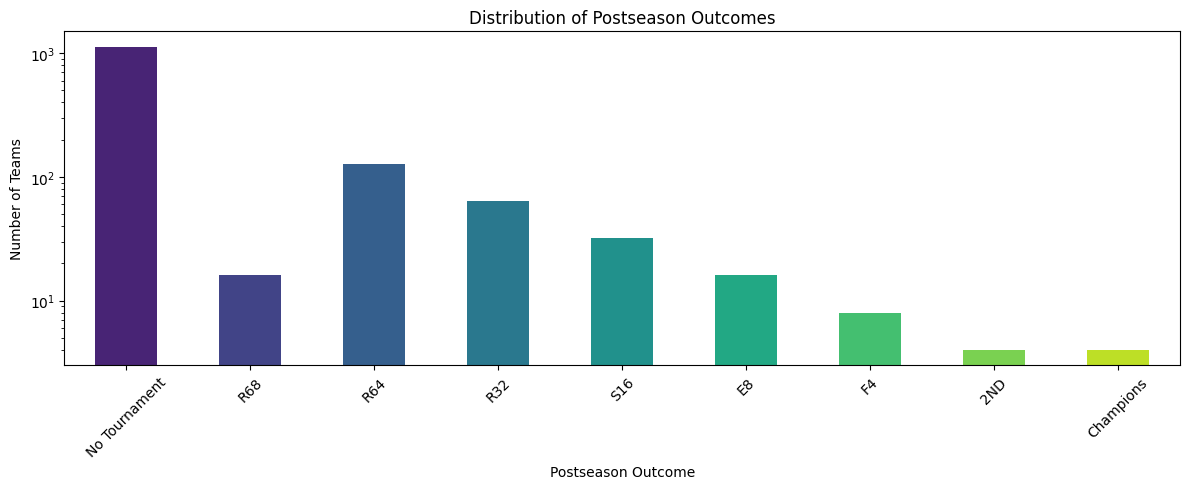

In [15]:
# Target Variable Analysis (POSTSEASON)

postseason_counts = df["POSTSEASON"].value_counts()
print("\n Postseason distribution: \n")
print(postseason_counts)

#Define tournament order for ordering plots
tournament_order = [
    "No Tournament", "R68", "R64", "R32", "S16", "E8", "F4", "2ND", "Champions"
]
#Only keep rounds that exist in the dataset
tournament_order = [r for r in tournament_order if r in df["POSTSEASON"].unique()]

plt.figure(figsize=(12, 5))
postseason_counts.reindex(tournament_order).plot(
    kind="bar", color = sns.color_palette("viridis", len(postseason_counts))
)
plt.title("Distribution of Postseason Outcomes")
plt.ylabel("Number of Teams")
plt.xlabel("Postseason Outcome")
plt.yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

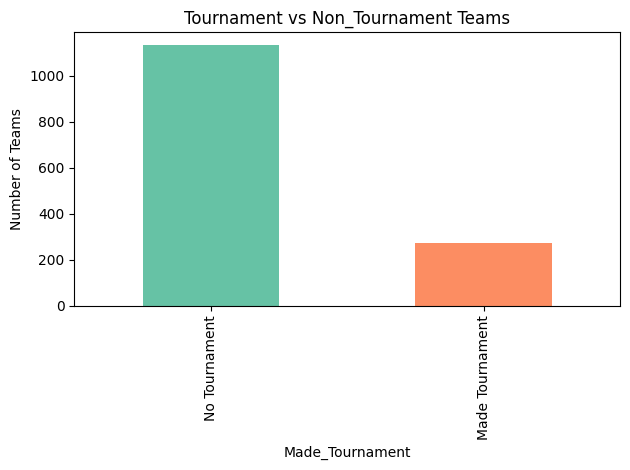

In [14]:
df["Made_Tournament"] = df["POSTSEASON"].apply(
    lambda x: "Made Tournament" if x != "No Tournament" else "No Tournament"
)
df["Made_Tournament"].value_counts().plot(
    kind="bar", color = sns.color_palette ("Set2", 2)
)
plt.title("Tournament vs Non_Tournament Teams")
plt.ylabel("Number of Teams")
plt.tight_layout()
plt.show()

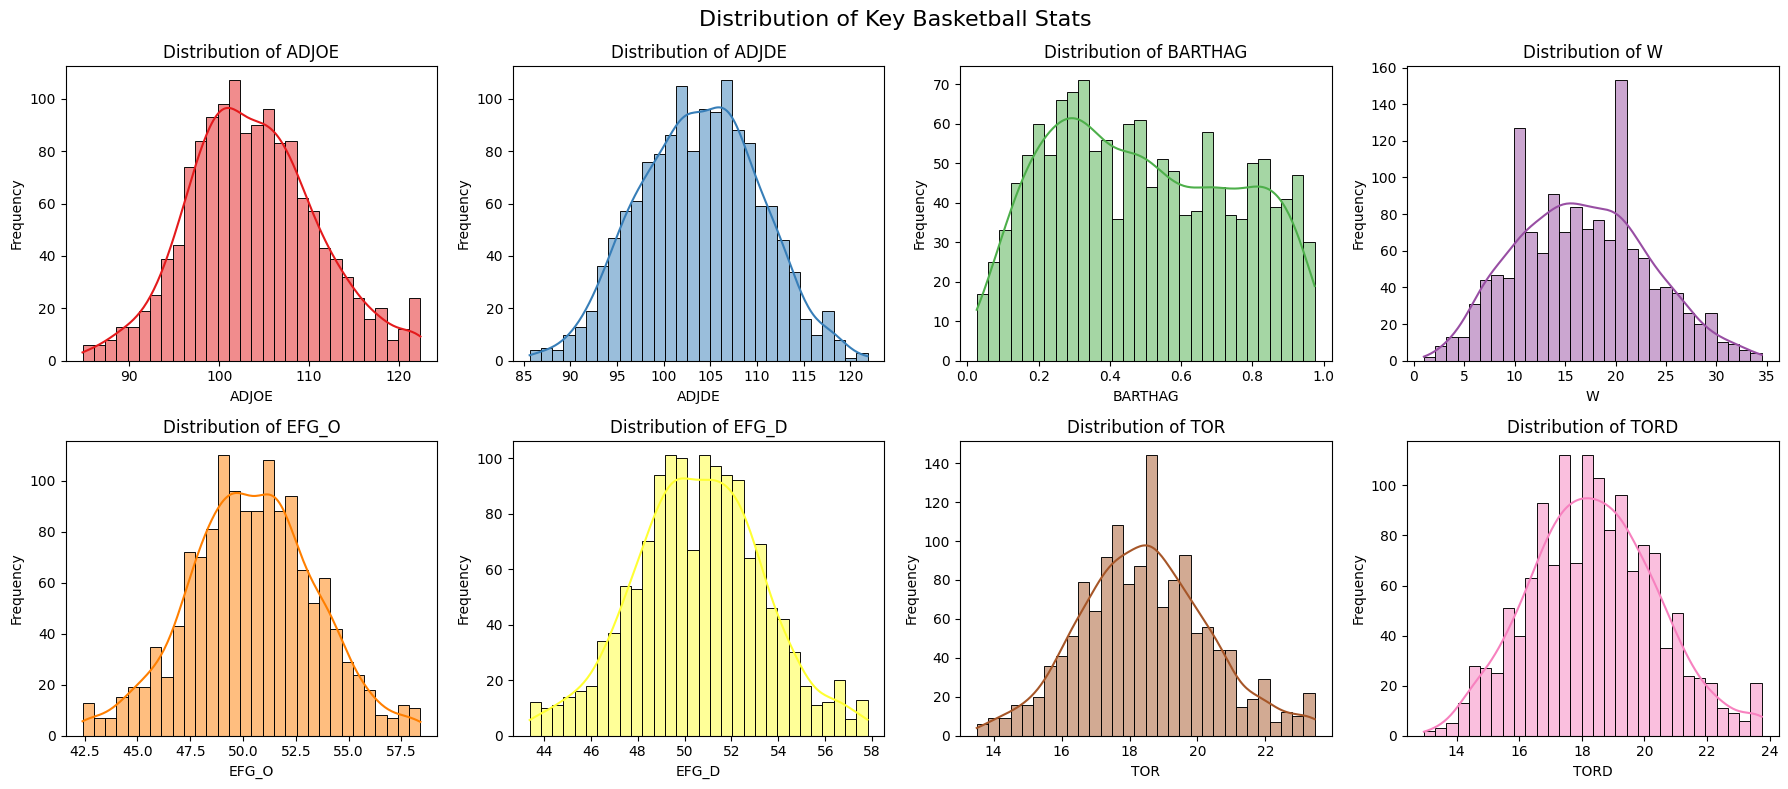

In [16]:
# Univariate Analysis

key_stats = ["ADJOE","ADJDE", "BARTHAG", "W", "EFG_O", "EFG_D", "TOR", "TORD"]
key_stats = [c for c in key_stats if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_stats):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=sns.color_palette("Set1")[i % 9])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Key Basketball Stats", fontsize = 16)
plt.tight_layout()
plt.show()



Average stats by postseason round:

                ADJOE   ADJDE  BARTHAG      W  EFG_O  EFG_D    TOR   TORD
POSTSEASON                                                               
2ND            117.45   89.31     0.96  32.88  54.15  45.65  15.82  19.40
Champions      122.05   91.60     0.97  34.12  55.35  47.00  15.55  18.73
E8             118.03   93.20     0.93  28.38  53.85  47.50  16.88  18.97
F4             116.30   93.56     0.92  29.50  53.99  47.31  17.86  19.68
No Tournament  101.89  105.43     0.42  14.79  49.85  51.14  18.74  18.29
R32            113.29   95.60     0.86  25.48  52.65  47.73  16.86  18.92
R64            109.32   99.21     0.72  23.12  52.39  48.86  17.54  18.62
R68            106.28  103.01     0.56  20.06  51.29  49.40  17.76  19.07
S16            116.68   94.58     0.91  27.25  53.53  47.84  16.93  18.48


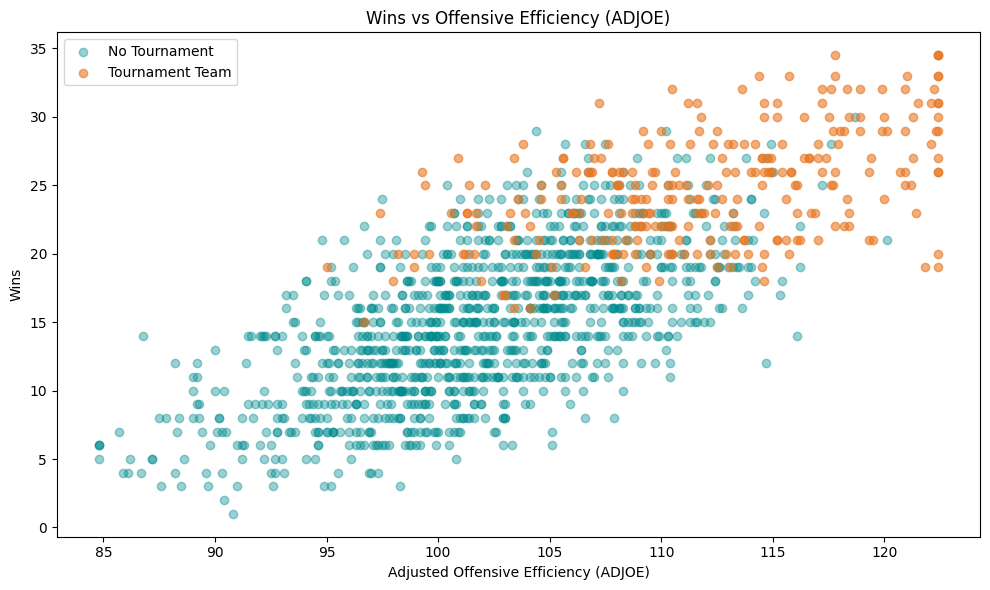

<Figure size 1200x500 with 0 Axes>

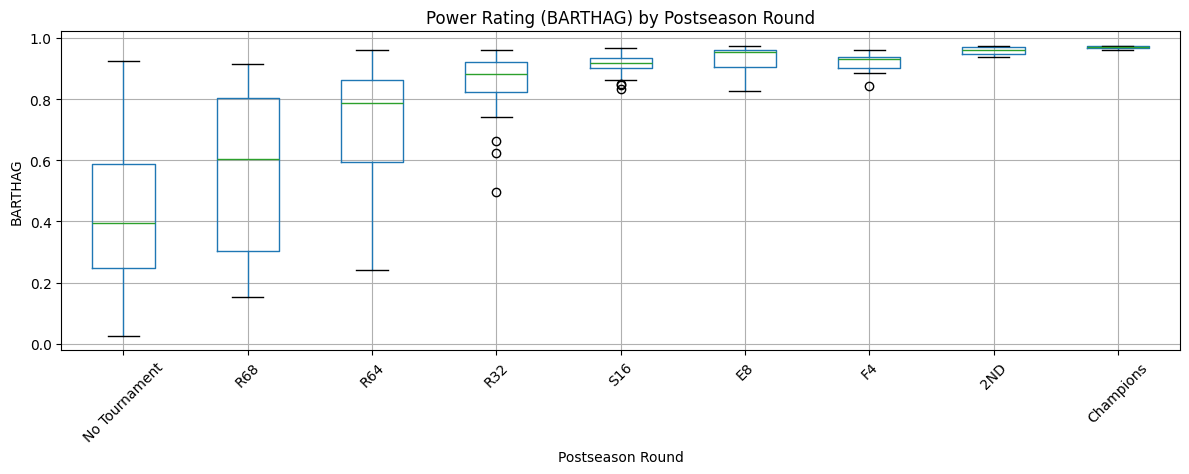

In [21]:
# Bivariate Analysis (Stats vs POSTSEASON)

avg_by_round = df.groupby("POSTSEASON")[key_stats].mean().round(2)
print("\nAverage stats by postseason round:\n")
print(avg_by_round)
 
# Wins vs Offensive Efficiency coloured by tournament participation
plt.figure(figsize=(10, 6))
tournament_teams = df["POSTSEASON"] != "No Tournament"
plt.scatter(
    df.loc[~tournament_teams, "ADJOE"],
    df.loc[~tournament_teams, "W"],
    alpha=0.4, label="No Tournament", color="#008B8E"
)

plt.scatter(
    df.loc[tournament_teams, "ADJOE"],
    df.loc[tournament_teams, "W"],
    alpha=0.6, label="Tournament Team", color="#E87722"
)
plt.title("Wins vs Offensive Efficiency (ADJOE)")
plt.xlabel("Adjusted Offensive Efficiency (ADJOE)")
plt.ylabel("Wins")
plt.legend()
plt.tight_layout()
plt.show()

#BARTHAG (Power Rating) by Postseason Round
plt.figure(figsize=(12, 5))
df_ordered = df.copy()
df_ordered["POSTSEASON"] = pd.Categorical(
    df_ordered["POSTSEASON"], categories=tournament_order, ordered=True
)
df_ordered.sort_values("POSTSEASON").boxplot(
    column="BARTHAG", by="POSTSEASON", figsize=(12, 5)
)
plt.title("Power Rating (BARTHAG) by Postseason Round")
plt.suptitle("")
plt.xlabel("Postseason Round")
plt.ylabel("BARTHAG")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Tournament appearances by conference:

CONF
ACC     32
B12     26
B10     26
SEC     23
BE      22
P12     17
Amer    13
A10     11
MWC      6
WCC      6
MVC      5
BSth     5
OVC      5
BW       4
CUSA     4
Ivy      4
SB       4
Slnd     4
AE       4
BSky     4
CAA      4
Horz     4
MAAC     4
MAC      4
MEAC     4
Pat      4
SC       4
Sum      4
WAC      4
NEC      4
SWAC     4
ASun     3
Name: count, dtype: int64


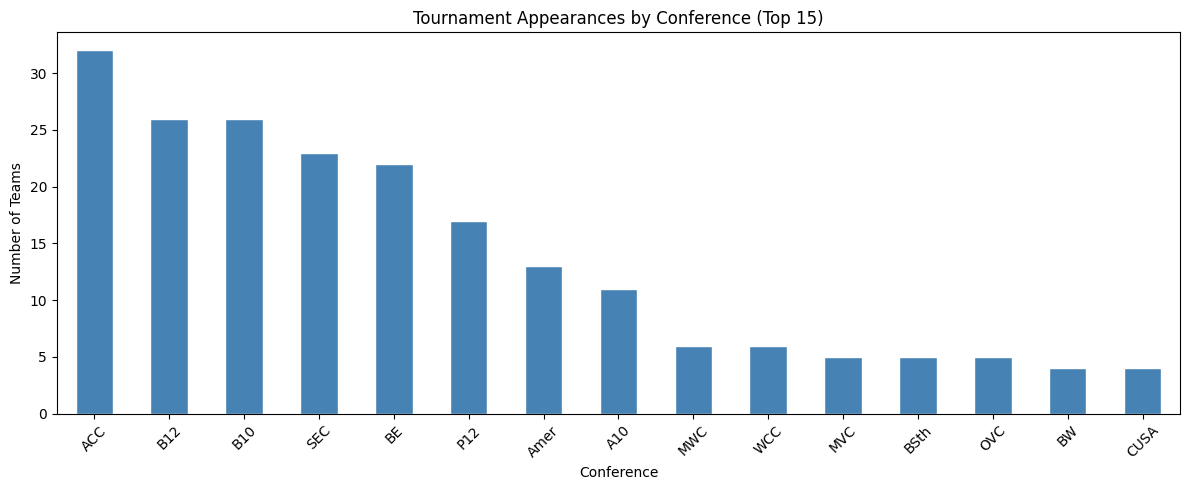


Average wins by conference (Top 10):

CONF
B12     21.50
ACC     21.11
BE      20.52
B10     20.41
SEC     19.73
P12     19.19
Amer    18.74
MAC     17.85
WCC     17.79
MWC     17.41
Name: W, dtype: float64


In [23]:
# Conference Analysis

# Count how many teams from each conference made the tournament (POSTSEASON != "No Tournament")
conf_tournament = df[df["POSTSEASON"] != "No Tournament"]["CONF"].value_counts()
print("\nTournament appearances by conference:\n")
print(conf_tournament)
 
plt.figure(figsize=(12, 5))
conf_tournament.head(15).plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Tournament Appearances by Conference (Top 15)")
plt.ylabel("Number of Teams")
plt.xlabel("Conference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Average wins per conference
avg_wins_conf = df.groupby("CONF")["W"].mean().sort_values(ascending=False)
print("\nAverage wins by conference (Top 10):\n")
print(avg_wins_conf.head(10).round(2))


Average stats per year:

       ADJOE   ADJDE      W
YEAR                       
2016  103.86  103.87  15.71
2017  103.83  103.83  17.00
2018  104.34  104.35  17.06
2019  103.33  103.34  17.11


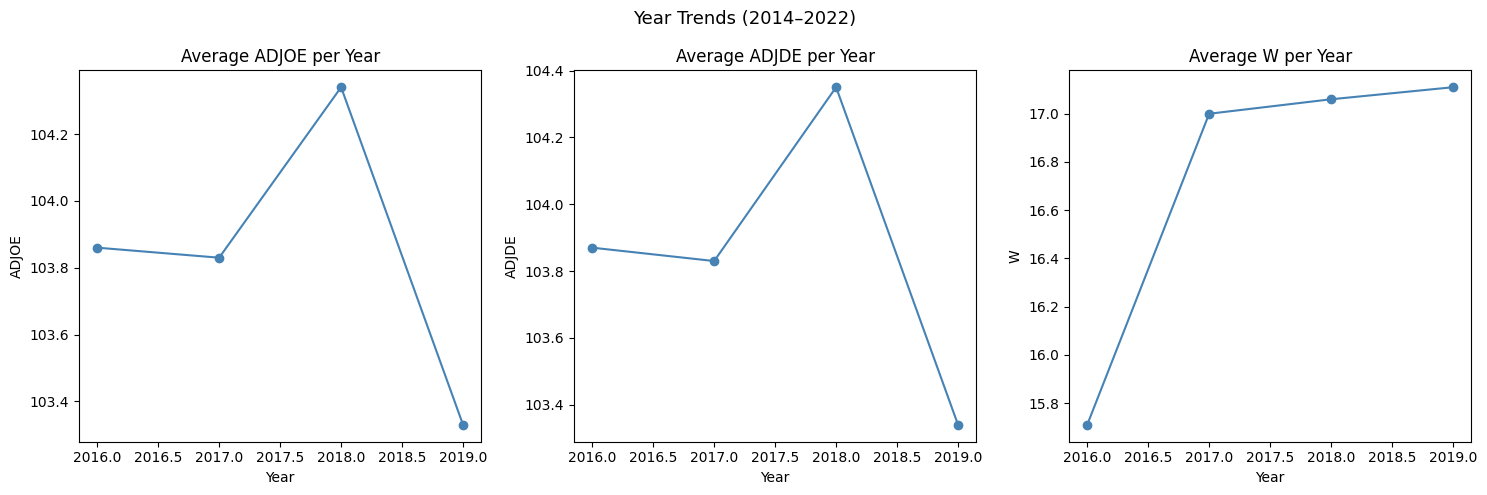

In [24]:
# Year Trends

yearly_stats = df.groupby("YEAR")[["ADJOE", "ADJDE", "W"]].mean().round(2)
print("\nAverage stats per year:\n")
print(yearly_stats)
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
for ax, col in zip(axes, ["ADJOE", "ADJDE", "W"]):
    yearly_stats[col].plot(ax=ax, marker="o", color="steelblue")
    ax.set_title(f"Average {col} per Year")
    ax.set_xlabel("Year")
    ax.set_ylabel(col)
 
plt.suptitle("Year Trends (2014–2022)", fontsize=13)
plt.tight_layout()
plt.show()


Top 10 strongest correlations:

Feature 1 Feature 2  Correlation  Abs Corr
  BARTHAG       WAB     0.943035  0.943035
        W       WAB     0.901793  0.901793
    EFG_D      2P_D     0.901106  0.901106
    EFG_O      2P_O     0.887343  0.887343
    ADJOE   BARTHAG     0.878267  0.878267
    ADJDE   BARTHAG    -0.855979  0.855979
    ADJOE       WAB     0.852974  0.852974
    ADJDE       WAB    -0.817103  0.817103
        W   BARTHAG     0.808574  0.808574
    ADJDE     EFG_D     0.789911  0.789911


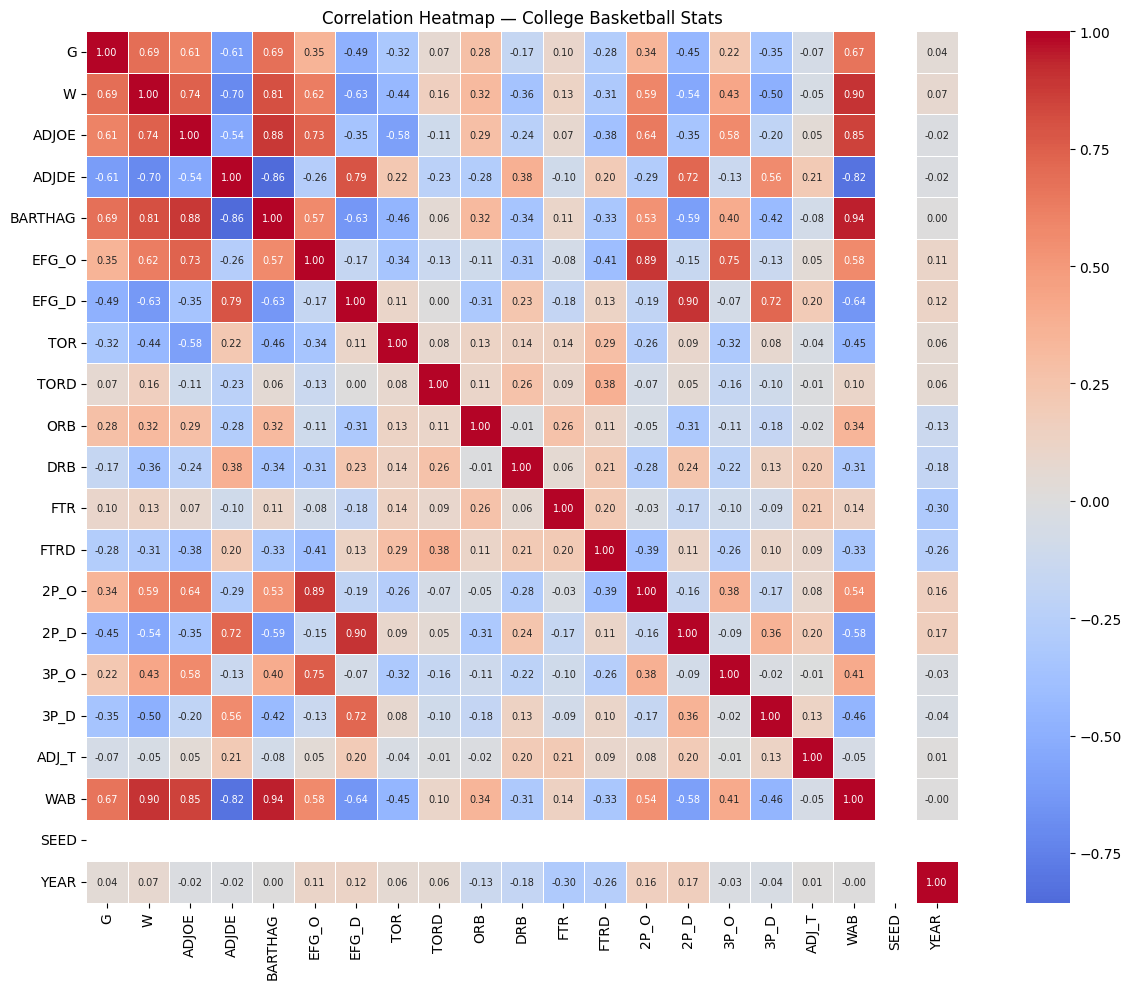


 EDA Complete — ready for Feature Engineering!


In [26]:
# Correlation Analysis 

corr = df.select_dtypes(include=np.number).corr()
 
# Top 10 strongest correlations
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
corr_pairs["Abs Corr"] = corr_pairs["Correlation"].abs()
print("\nTop 10 strongest correlations:\n")
print(corr_pairs.sort_values("Abs Corr", ascending=False).head(10).to_string(index=False))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=0.4,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap — College Basketball Stats")
plt.tight_layout()
plt.show()
 
print("\n EDA Complete — ready for Feature Engineering!")
 